# 项目 3-1（★）numpy 实现两层网络解 XOR

- **练到**：层间全连接 + 非线性激活
- **任务**：用 numpy 手写一个"输入 2 → 隐藏 2 → 输出 1"的两层网络（隐藏层用 tanh 或 ReLU），手写前向 + 简单梯度，训练它学会 XOR。
- **验收**：4 个样本全部预测正确；能画出隐藏层两个神经元各自学到的"分割线"。

## 三个函数说明

### 1. tanh（双曲正切）函数

- **定义**：$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
- **值域**：$(-1, 1)$
- **性质**：奇函数，单调递增，处处可导
- **导数**：$\tanh'(x) = 1 - \tanh^2(x)$

### 2. ReLU（修正线性单元）函数

- **定义**：$\text{ReLU}(x) = \max(0, x)$
- **值域**：$[0, +\infty)$
- **性质**：分段线性，非光滑（在 $x=0$ 处不可导）
- **导数**：$x > 0$ 时为 1；$x < 0$ 时为 0

### 3. Sigmoid（Logistic）函数

- **定义**：$\sigma(x) = \frac{1}{1 + e^{-x}}$
- **值域**：$(0, 1)$
- **性质**：单调递增，处处可导，S 形曲线
- **导数**：$\sigma'(x) = \sigma(x)(1 - \sigma(x))$

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 样本数据
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0]).reshape(-1, 1)

In [24]:
# ========= 1. 初始化参数 =========
np.random.seed(42)

# W1: (2, 2), b1: (1, 2) 输入 2，隐藏 2
W1 = np.array([[1.0, -1.0], [1.0, -1.0]])
b1 = np.array([[-0.5, 1.5]])

# W2: (2, 1), b2: (1, 1) 隐藏 2，输出 1
W2 = np.array([[1.0], [1.0]])
b2 = np.array([[-1.5]])

# 学习率与轮次
lr, epochs = 1.0, 15000

# 激活函数以及导数
def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

loss_history = []

In [25]:
# ========= 2.训练循环：手写前向 + 反向传播 =========
for epoch in range(epochs):
    # -------- 前向传播 --------
    z1 = X @ W1 + b1    # (4, 2)
    h1 = tanh(z1)       # 隐藏层输出 (4, 2)
    z2 = h1 @ W2 + b2   # (4, 1)
    y_hat = sigmoid(z2) # 网络预测 (4, 1)

    # MSE 损失
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # -------- 反向传播 手写梯度 --------
    # 输出层梯度
    delta2 = (y_hat - y) * sigmoid_deriv(z2) # (4, 1)
    dW2 = h1.T @ delta2 / 4
    db2 = np.sum(delta2, axis=0, keepdims=True) / 4

    # 隐藏层梯度
    delta1 = (delta2 @ W2.T) * tanh_deriv(z1) # (4, 2)
    dW1 = X.T @ delta1 / 4
    db1 = np.sum(delta1, axis=0, keepdims=True) / 4

    # 参数更新 SGD
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    # 打印进度
    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d} | loss: {loss:.4f}")

epoch     0 | loss: 0.2381
epoch  1000 | loss: 0.0023
epoch  2000 | loss: 0.0010
epoch  3000 | loss: 0.0006
epoch  4000 | loss: 0.0005
epoch  5000 | loss: 0.0004
epoch  6000 | loss: 0.0003
epoch  7000 | loss: 0.0003
epoch  8000 | loss: 0.0002
epoch  9000 | loss: 0.0002
epoch 10000 | loss: 0.0002
epoch 11000 | loss: 0.0002
epoch 12000 | loss: 0.0001
epoch 13000 | loss: 0.0001
epoch 14000 | loss: 0.0001


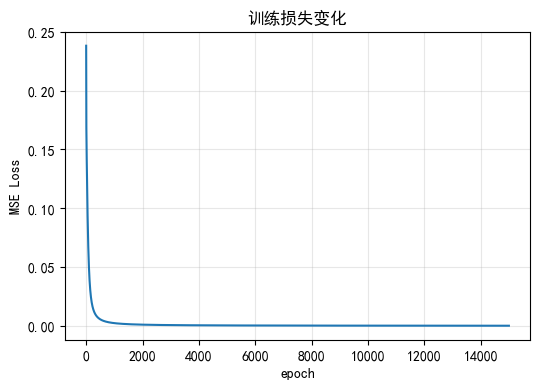

In [26]:
# ========= 3.loss 下降曲线 =========
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("训练损失变化")
plt.xlabel("epoch")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.show()

In [27]:
# ========= 4.训练结束，预测4个XOR样本 =========
print("===== 4 个样本预测结果 =====")
z1 = X @ W1 + b1
h1 = tanh(z1)
z2 = h1 @ W2 + b2
y_hat = sigmoid(z2)
for i in range(4):
    print(f"输入 {X[i]} 真实y={y[i,0]} 预测y_hat={y_hat[i,0]:.4f}")

===== 4 个样本预测结果 =====
输入 [0 0] 真实y=0 预测y_hat=0.0120
输入 [0 1] 真实y=1 预测y_hat=0.9911
输入 [1 0] 真实y=1 预测y_hat=0.9911
输入 [1 1] 真实y=0 预测y_hat=0.0123


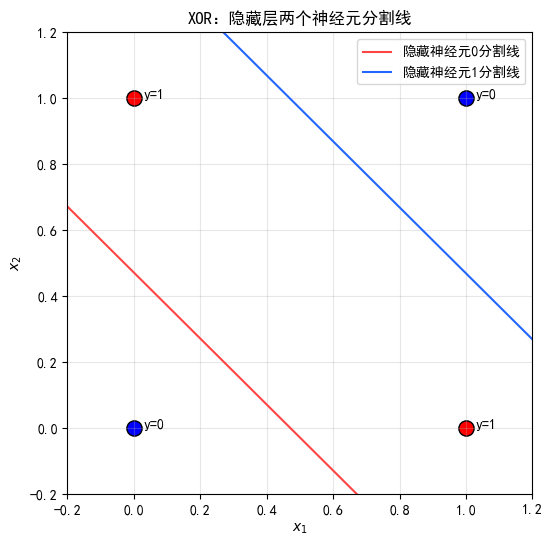

In [ ]:
# ========= 5.绘制 XOR 样本点 + 隐藏层两个神经元分割线 =========
plt.figure(figsize=(6, 6))

# 画原始 XOR 四个点
for idx, (x1, x2) in enumerate(X):
    yi = y[idx, 0]
    c = 'red' if yi==1 else 'blue'
    plt.scatter(x1, x2, color=c, s=120, edgecolors='k')
    plt.text(x1+0.03, x2, f"y={int(yi)}")

x_line = np.linspace(-0.2, 1.2, 100)

# 隐藏神经元 0 的分割线 w1[:, 0], b1[0, 0]
w1_0 = W1[:, 0]
b1_0 = b1[0, 0]
x2_0 = (-w1_0[0] * x_line - b1_0) / w1_0[1]
plt.plot(x_line, x2_0, label="隐藏神经元 0 分割线", c="#ff4444")

# 隐藏神经元 1 的分割线 w1[:,1], b1[0,1]
w1_1 = W1[:, 1]
b1_1 = b1[0, 1]
x2_1 = (-w1_1[0] * x_line - b1_1) / w1_1[1]
plt.plot(x_line, x2_1, label="隐藏神经元 1 分割线", c="#2266ff")

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("XOR：隐藏层两个神经元分割线")
plt.legend()
plt.grid(alpha=0.3)
plt.show()